In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from regions import Regions
import regions
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy import units as u
from astropy.modeling import models, fitting
from astropy.table import Table, vstack

from dust_extinction.averages import CT06_MWGC

from smart_plotters.jwst_plots import JWSTCatalog, make_cat_use, make_brick_cat
from smart_plotters.cutout_plot import get_cutout_405, get_cutout_jwst_ice
import smart_plotters.co_ice as co_map 
from smart_plotters import cmd_plot 

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead. [astropy.tests.runner]
        Use pytest instead. [astropy.utils.decorators]


In [2]:
cat_brick = make_brick_cat()
cat_brick.catalog['Av'] = cat_brick.get_Av('f182m', 'f212n')
cat_brick.catalog['N(CO)'] = co_map.get_co_ice_column(cat_brick, cat_brick.catalog['Av'], ext=CT06_MWGC(), ref_band='f405n')

Reading /orange/adamginsburg/jwst/brick/catalogs/basic_merged_indivexp_photometry_tables_merged_qualcuts_oksep2221.fits


In [3]:
def get_rc_sel_mask(cat):
    x = np.linspace(0, 2.5, 10)
    
    x0 = 0.52
    mask_x0_left = cat.color('f182m', 'f212n') > x0

    y0 = 14.8
    mask_above_y0 = cat.band('f182m') > y0
    mask_rc = mask_above_y0 & mask_x0_left

    pt1 = (0.5, 14.3)
    pt2 = (2.0, 20.)
    y1 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_below_y1 = cat.band('f182m') > ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_below_y1 & mask_rc

    pt1 = (0.5, 15.5)
    pt2 = (2.0, 20.9)
    y2 = (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (x - pt1[0]) + pt1[1]
    mask_above_y2 = cat.band('f182m') < ( (pt2[1] - pt1[1]) / (pt2[0] - pt1[0]) * (cat.color('f182m', 'f212n') - pt1[0]) + pt1[1] )
    mask_rc = mask_rc & mask_above_y2

    return mask_rc

In [4]:
cat_brick_rc = JWSTCatalog(cat_brick.catalog[get_rc_sel_mask(cat_brick)])

In [5]:
reg_brick_north = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_north.reg')
reg_brick_south = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_south.reg')
reg_brick_head = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_head.reg')
reg_brick_sfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfluff.reg')
reg_brick_nfluff = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nfluff.reg')
reg_brick_sfr = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr_tight.reg')
reg_brick_sfrwide = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr.reg')
reg_brick_punch = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_punch.reg')
reg_brick_sfore = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfore.reg')
reg_brick_nclear = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_nclear.reg')
#reg_brick_topL = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_topL.reg')
reg_brick_topc = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_topc.reg')
#reg_brick_fil = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_fil.reg')
reg_brick_middle = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_middle.reg')

reg_brick_sfr_tightest = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_sfr_tightest.reg')


reg_brick_A = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_A.reg')
reg_brick_B = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_B.reg')
reg_brick_C = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_C.reg')
reg_brick_D = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/brick_D.reg')

reg_brick_claw1 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/claw1.reg')
reg_brick_claw2 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/claw2.reg')
reg_brick_claw3 = Regions.read('/orange/adamginsburg/jwst/cloudc/regions_/claw3.reg')

In [6]:
fn_brick = '/orange/adamginsburg/jwst/brick/F405N/pipeline/jw02221-o001_t001_nircam_clear-f405n-merged_i2d.fits'
hdu_brick = fits.open(fn_brick)
ww_brick = WCS(hdu_brick['SCI'].header)
nanfield_brick = np.nan * hdu_brick['SCI'].data

In [7]:
from astropy.wcs.utils import proj_plane_pixel_scales


def get_angular_area(reg, ww):
    pix_scales = proj_plane_pixel_scales(ww) * u.deg / u.pix
    pix_area = (reg[0].to_pixel(ww).area*u.pix**2) # convert to arcsec^2 then parsec^2
    pixel_to_angle = pix_scales[0] * pix_scales[1] # deg^2 / pix^2
    angle_area = pix_area * pixel_to_angle # area in degrees
    
    return angle_area.to(u.arcsec**2)

def get_physical_area(reg, ww, distance=8100*u.pc):
    angle_area = get_angular_area(reg, ww)
    parsec_area = angle_area.to(u.rad**2) * (8100*u.pc)**2 / u.rad**2

    return parsec_area

def find_foreground_stellar_density(cat, reg, ww):
    ang_area = get_angular_area(reg, ww)
    cat_fore = cat.catalog[cat.color('f182m', 'f212n') < 0.55]
    num_fore = len(cat_fore)
    density = num_fore / ang_area
    return density

def find_stellar_density(cat, reg, ww):
    ang_area = get_angular_area(reg, ww)
    num = len(cat)
    density = num / ang_area
    return density

In [8]:
cat_brick_A = JWSTCatalog(cat_brick.table_region_mask(reg_brick_A, ww_brick))
cat_brick_B = JWSTCatalog(cat_brick.table_region_mask(reg_brick_B, ww_brick))
cat_brick_C = JWSTCatalog(cat_brick.table_region_mask(reg_brick_C, ww_brick))
cat_brick_D = JWSTCatalog(cat_brick.table_region_mask(reg_brick_D, ww_brick))

cat_brick_A_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_A, ww_brick))
cat_brick_B_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_B, ww_brick))
cat_brick_C_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_C, ww_brick))
cat_brick_D_rc = JWSTCatalog(cat_brick_rc.table_region_mask(reg_brick_D, ww_brick))

In [31]:
def remove_fore_mask(cat):
    mask_1 = cat.color('f182m', 'f212n') > 0.55
    mask_2 = cat.color('f115w', 'f200w') > 4
    mask_combo = np.logical_or(mask_1, mask_2)
    return mask_combo

cat_brick_A_n = JWSTCatalog(cat_brick_A.catalog[remove_fore_mask(cat_brick_A)])
cat_brick_B_n = JWSTCatalog(cat_brick_B.catalog[remove_fore_mask(cat_brick_B)])
cat_brick_C_n = JWSTCatalog(cat_brick_C.catalog[remove_fore_mask(cat_brick_C)])
cat_brick_D_n = JWSTCatalog(cat_brick_D.catalog[remove_fore_mask(cat_brick_D)])

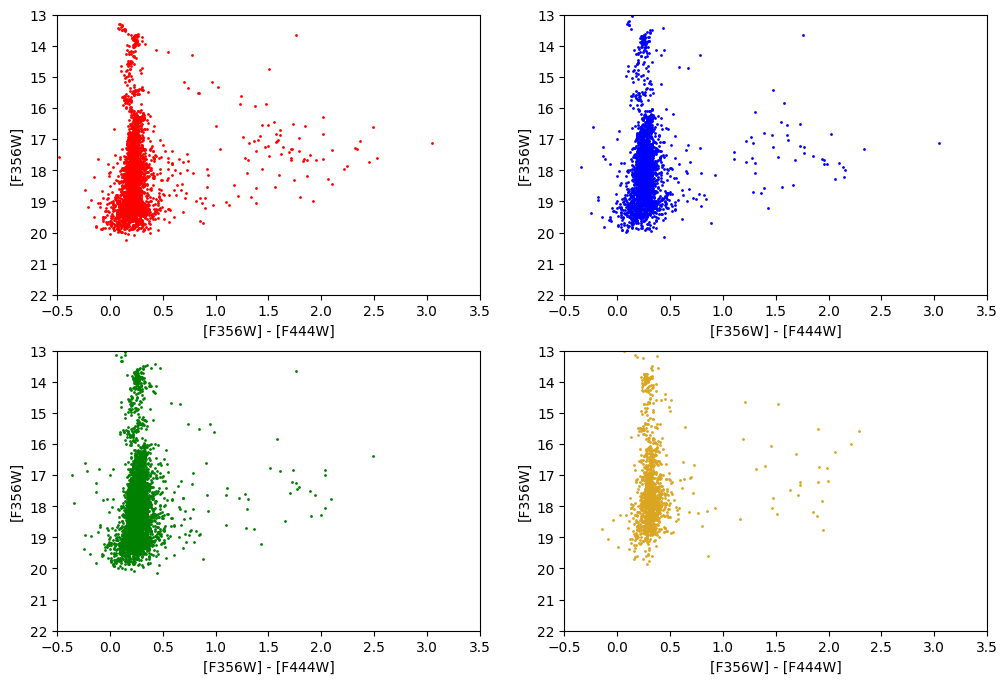

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cats = [cat_brick_A_n, cat_brick_B_n, cat_brick_C_n, cat_brick_D_n]
colors = ['red', 'blue', 'green', 'goldenrod']

for i in range(4):
    ax = axes.flatten()[i]
    cat = cats[i]
    cat.plot_CMD('f356w', 'f444w', 'f356w', color=colors[i], s=1, ax=ax)
    ax.set_ylim(22, 13)
    ax.set_xlim(-0.5, 3.5)

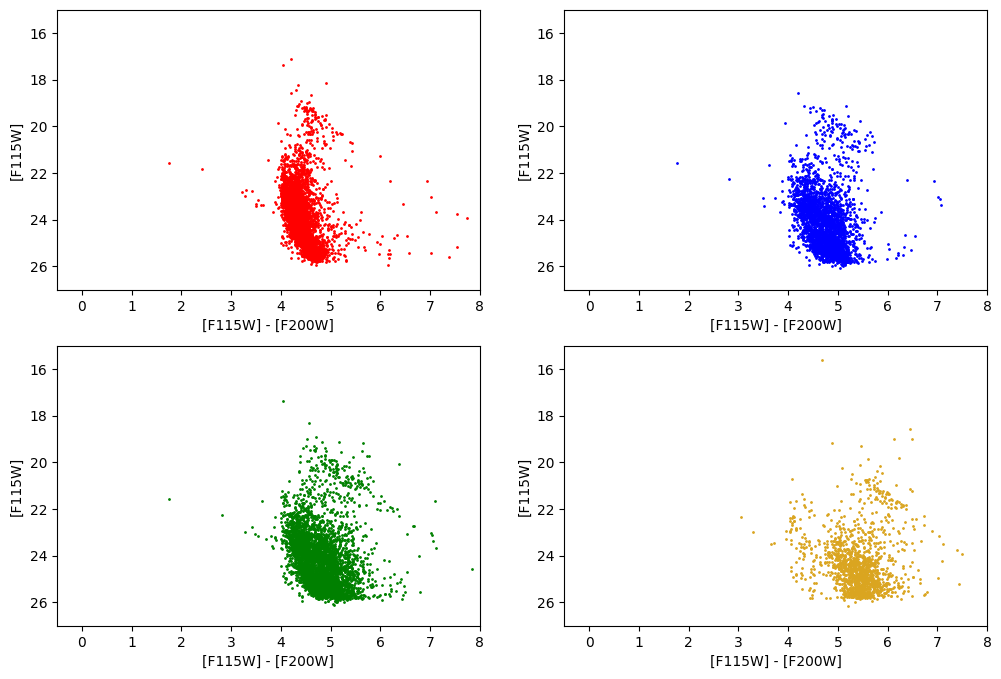

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
cats = [cat_brick_A_n, cat_brick_B_n, cat_brick_C_n, cat_brick_D_n]
colors = ['red', 'blue', 'green', 'goldenrod']

for i in range(4):
    ax = axes.flatten()[i]
    cat = cats[i]
    cat.plot_CMD('f115w', 'f200w', 'f115w', color=colors[i], s=1, ax=ax)
    ax.set_ylim(27, 15)
    ax.set_xlim(-0.5, 8)

In [12]:
axes

array([[<Axes: >, <Axes: >],
       [<Axes: >, <Axes: >]], dtype=object)